# MVP UI Demo (CLI + Notebook)

Этот notebook демонстрирует прикладной сценарий пользователя поверх аналитического модуля.

In [1]:
from pathlib import Path
from IPython.display import display, Image
from hidden_patterns_combat.ui import run_demo_workflow

In [2]:
from pathlib import Path
import os

# перейти в корень проекта (где README.md)
os.chdir("/Users/dmitryaleshkin/Documents/hidden-patterns-combat")
print(Path.cwd())

excel_path = "/Users/dmitryaleshkin/Documents/hidden-patterns-combat/data/raw/episodes.xlsx"

/Users/dmitryaleshkin/Documents/hidden-patterns-combat


In [3]:
excel_path = 'data/raw/episodes.xlsx'
sheet_name = 'Общее'  # None -> все листы
episode_index = 0

result = run_demo_workflow(
    excel_path=excel_path,
    sheet=sheet_name,
    model_path='artifacts/hmm_model.pkl',
    preprocess_output_dir='data/processed/preprocessing',
    analysis_output_dir='artifacts/analysis',
    episode_index=episode_index,
    n_states=3,
    retrain=False,
)
result_dict = result.to_dict()
result_dict

{'preprocessing': {'excel_path': 'data/raw/episodes.xlsx',
  'sheets_loaded': ['Общее'],
  'rows_raw': 969,
  'rows_cleaned': 969,
  'columns_cleaned': 70,
  'validation': {'is_valid': True,
   'missing_blocks': [],
   'present_blocks': ['kfv', 'maneuvering', 'metadata', 'outcomes', 'vup'],
   'row_count': 969,
   'column_count': 70},
  'exports': {'raw_csv': 'data/processed/preprocessing/raw_combined.csv',
   'cleaned_csv': 'data/processed/preprocessing/cleaned_tidy.csv',
   'mapping_csv': 'data/processed/preprocessing/data_dictionary.csv',
   'validation_json': 'data/processed/preprocessing/validation.json'}},
 'analysis': {'rows': 968,
  'log_likelihood': 12444.28548341549,
  'analysis_csv': 'artifacts/analysis/episode_analysis.csv',
  'profile_csv': 'artifacts/analysis/state_profile.csv',
  'summary_path': 'artifacts/analysis/interpretation.txt',
  'plots': ['artifacts/analysis/hidden_state_sequence.png',
   'artifacts/analysis/state_probability_profile.png',
   'artifacts/analysis

In [4]:
print('Ключевые признаки эпизода:')
for k, v in result_dict['episode_insight']['key_features'].items():
    print(f'  {k}: {v}')

print('\nВероятный скрытый сценарий:')
print(result_dict['episode_insight']['hidden_state'])

print('\nКраткий интерпретируемый вывод:')
print(result_dict['interpretation_text'])

Ключевые признаки эпизода:
  maneuver_right_code: 0.0
  maneuver_left_code: 0.0
  grips_code: 0.0
  holds_code: 0.0
  bodylocks_code: 0.0
  underhooks_code: 0.0
  posts_code: 0.0
  kfv_code: 0.0
  vup_code: 0.0
  outcome_actions_code: 0.0
  observed_result: 0.0

Вероятный скрытый сценарий:
state_1

Краткий интерпретируемый вывод:
Latent state state_0: n=153, maneuverR=4.28, maneuverL=2.54, KFV=10.57, VUP=1.37, result=2.04
Latent state state_1: n=623, maneuverR=3.28, maneuverL=1.46, KFV=2.68, VUP=0.41, result=0.00
Latent state state_2: n=192, maneuverR=3.66, maneuverL=0.96, KFV=18.21, VUP=1.17, result=0.00


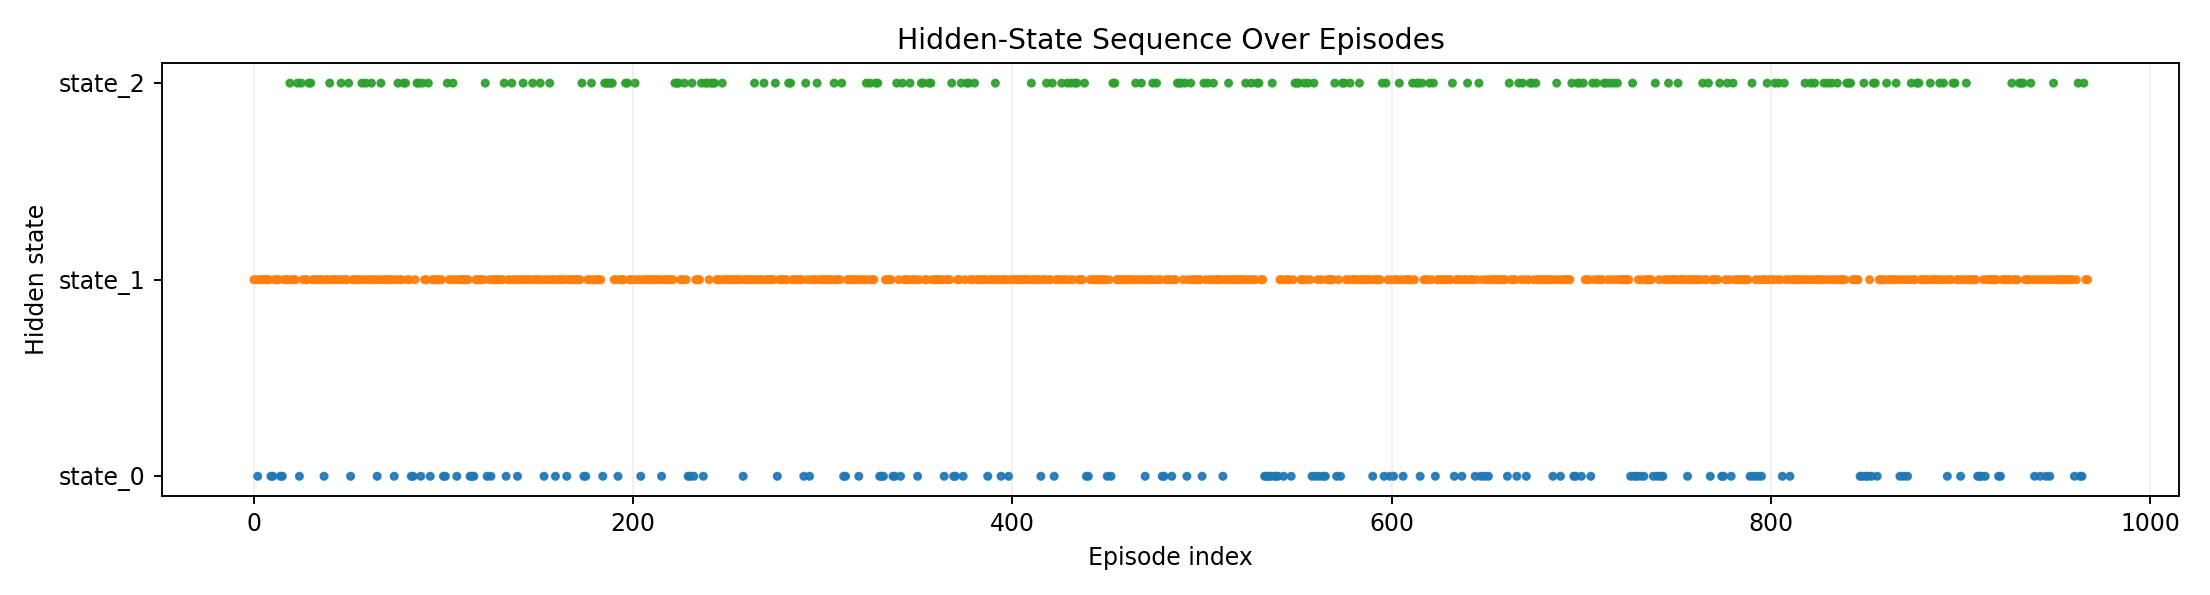

In [5]:
plot_path = result_dict.get('visualization_path')
if plot_path and Path(plot_path).exists():
    display(Image(filename=plot_path))
else:
    print('Визуализация не найдена')